# KTIR Latency Estimation Demo

This notebook shows how to use `ktir_cpu` to get cycle-approximate latency estimates
for KTIR kernels — no Spyre hardware required.

**What we cover:**
1. Load a kernel and run it (regex parser, no extra dependencies)
2. Inspect the `LatencyReport` — cycles, time, bottleneck, roofline
3. Compare two kernels (matmul vs softmax)
4. Multi-kernel roofline: matmul, softmax, sdpa, paged attention
5. Per-op trace: paged attention (indirect K/V loads via block_tables)
6. Tune `HardwareConfig` to model different hardware targets
7. Using the MLIR frontend parser (optional, requires `mlir_ktdp`)


## Setup

```bash
uv sync --group dev   # installs jupyter + matplotlib
```

Then launch:

```bash
uv run jupyter notebook notebooks/latency_demo.ipynb
```

In [17]:
import os, pathlib
import numpy as np
from ktir_cpu.interpreter import KTIRInterpreter
from ktir_cpu.latency import HardwareConfig

# Resolve paths relative to the repo root regardless of launch directory.
# The notebook lives in notebooks/, so the repo root is one level up.
_REPO = pathlib.Path(__file__).parent.parent if "__file__" in dir() else pathlib.Path.cwd()
if not (_REPO / "examples" / "latency").exists():
    _REPO = _REPO.parent   # launched from notebooks/
_LATENCY = _REPO / "examples" / "latency"

In [18]:
import matplotlib.pyplot as plt

def plot_roofline(hw: HardwareConfig, kernels: list[tuple[str, object]], title: str = "Roofline") -> None:
    """One subplot per dominant unit (stacked vertically); x-axis zoomed to kernel region."""
    clock   = hw.clock_ghz * 1e9
    peak_bw = hw.hbm_bytes_per_cycle_per_core * clock / 1e9  # GB/s per-core

    unit_peaks = {
        "systolic": hw.systolic_flops_per_cycle * clock / 1e9,
        "simd":     hw.simd_elements_per_cycle  * clock / 1e9,
    }

    rfs = [(name, rep.roofline()) for name, rep in kernels]

    from collections import defaultdict
    groups: dict[str, list] = defaultdict(list)
    for name, rf in rfs:
        groups[rf["dominant_unit"]].append((name, rf))

    n_panels = len(groups)
    fig, axes = plt.subplots(n_panels, 1, figsize=(7, 4 * n_panels), squeeze=False)
    fig.suptitle(title, fontsize=12)

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for row, (unit, kgroup) in enumerate(groups.items()):
        ax = axes[row][0]
        peak_gflops = unit_peaks[unit]
        ridge       = peak_gflops / peak_bw

        ais       = [rf["arithmetic_intensity"] for _, rf in kgroup]
        achieveds = [rf["units"][unit]["achieved_gflops"] for _, rf in kgroup]
        max_ai    = max(ais)

        if ridge <= max_ai * 3:
            ai_max = ridge * 1.3
            show_ridge_in_plot = True
        else:
            ai_max = max_ai * 2.5
            show_ridge_in_plot = False

        ai_range = np.linspace(0, ai_max, 400)
        roof     = np.minimum(peak_bw * ai_range, peak_gflops)

        ax.plot(ai_range, roof, color="gray", linewidth=2, label="Roofline")

        if show_ridge_in_plot:
            ax.axvline(ridge, color="gray", linestyle="--", linewidth=1, alpha=0.6)
            ax.text(ridge * 1.02, peak_gflops * 0.5,
                    f"ridge={ridge:.1f} F/B", color="gray", fontsize=8, va="center")
        else:
            ax.axhline(peak_gflops, color="gray", linestyle="--", linewidth=1, alpha=0.5)
            ax.annotate(
                f"ridge={ridge:.0f} F/B →",
                xy=(ai_max, peak_bw * ai_max),
                xytext=(ai_max * 0.82, (peak_bw * ai_max) * 1.22),
                fontsize=8, color="gray",
                arrowprops=dict(arrowstyle="->", color="gray", lw=1),
            )

        for i, (name, rf) in enumerate(kgroup):
            u        = rf["units"][unit]
            achieved = u["achieved_gflops"]
            ceiling  = u["ceiling_gflops"]
            eff      = u["efficiency"]
            ai       = rf["arithmetic_intensity"]
            c        = colors[i % len(colors)]

            ax.scatter(ai, achieved, s=90, zorder=5, color=c,
                       label=f"{name}  (AI={ai:.2f} F/B, {achieved:.1f} GFLOP/s, eff={eff:.0%})")
            ax.plot([ai, ai], [achieved, min(ceiling, (peak_bw * ai_max) * 1.5)],
                    color=c, lw=1, linestyle="dotted")

        y_top = (peak_bw * ai_max * 1.3) if not show_ridge_in_plot else peak_gflops * 1.15
        ax.set_xlim(left=0, right=ai_max)
        ax.set_ylim(bottom=0, top=y_top)
        ax.set_xlabel("Arithmetic intensity (FLOP/B)", fontsize=10)
        ax.set_ylabel("Performance (GFLOP/s)", fontsize=10)
        ax.set_title(f"Dominant unit: {unit}", fontsize=10)
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(True, linestyle=":", alpha=0.4)

    plt.tight_layout()
    plt.show()


## 1. Matmul — load, run, report

**Kernel:** `examples/latency/matmul_small.mlir`  
Grid `[2, 2]` (4 cores), each core accumulates an 8×32 output tile over K=64 steps.

In [19]:
hw = HardwareConfig()

interp = KTIRInterpreter(latency_config=hw)
interp.load(str(_LATENCY / "matmul_small.mlir"))

In [20]:
M, K, N = 16, 64, 64
a = np.random.rand(M, K).astype(np.float16)
b = np.random.rand(K, N).astype(np.float16)
c = np.zeros((M, N), dtype=np.float16)

outputs = interp.execute_function(
    "matmul_kernel_small",
    a_ptr=a, b_ptr=b, c_ptr=c,
    K=K, BLOCK_SIZE_M=8, BLOCK_SIZE_N=32, BLOCK_SIZE_K=32,
)

# Verify correctness against NumPy
expected = a @ b
print("Max abs error:", np.max(np.abs(outputs["c_ptr"].astype(np.float32) - expected.astype(np.float32))))

Max abs error: 0.015625


In [21]:
report = interp.get_latency_report()
print(report)

KTIR Latency Estimation Report
  Kernel cycles : 352
  Kernel time   : 0.352 us
  Bottleneck    : memory
  Cores         : 4
------------------------------------------------------------
  Core       Compute        Memory          Comm         Total
------------------------------------------------------------
     0             8           344             0           352
     1             8           344             0           352
     2             8           344             0           352
     3             8           344             0           352

Roofline Analysis (critical-path core)
------------------------------------------------------------
  Arithmetic intensity : 3.10 FLOP/B
  Peak bandwidth       : 31.25 GB/s
  Dominant unit        : systolic
  Efficiency           : 96.2%  (dominant unit)

        Unit      Achieved       Ceiling       Ridge      Eff
  ----------  ------------  ------------  ----------  -------
 *   systolic       93.06 G       96.73 G   16777.2 F/B  

### Reading the report

| Field | Meaning |
|---|---|
| `kernel_cycles` | Max total cycles across all cores (critical path) |
| `kernel_time_us` | Cycles ÷ clock (default 1 GHz → 1 cycle = 1 ns) |
| `bottleneck` | Which category dominates the critical-path core: `compute`, `memory`, or `comm` |
| Per-core table | `compute_cycles`, `memory_cycles`, `comm_cycles` per core |
| Arithmetic intensity | FLOPs ÷ bytes transferred (FLOP/B) |
| Ridge point | AI where BW ceiling meets compute ceiling — left = memory-bound, right = compute-bound |

In [22]:
print(f"Kernel cycles : {report.kernel_cycles:,.0f}")
print(f"Kernel time   : {report.kernel_time_us:.3f} us")
print(f"Bottleneck    : {report.bottleneck}")

rf = report.roofline()
dominant = rf["dominant_unit"]
u = rf["units"][dominant]
print(f"\nRoofline summary  (dominant unit: {dominant})")
print(f"  Arithmetic intensity : {rf['arithmetic_intensity']:.2f} FLOP/B")
print(f"  Ridge point          : {u['ridge_point']:.2f} FLOP/B")
print(f"  Efficiency           : {rf['efficiency']:.1%}")
print(f"  Kernel is {'compute-bound' if rf['arithmetic_intensity'] >= u['ridge_point'] else 'memory-bound'}")

Kernel cycles : 352
Kernel time   : 0.352 us
Bottleneck    : memory

Roofline summary  (dominant unit: systolic)
  Arithmetic intensity : 3.10 FLOP/B
  Ridge point          : 16777.22 FLOP/B
  Efficiency           : 96.2%
  Kernel is memory-bound


## 2. Per-core breakdown

In [23]:
per_core = report.per_core_summary()
header = f"{'core':>4}  {'compute':>12}  {'memory':>12}  {'comm':>12}  {'total':>12}"
print(header)
print("-" * len(header))
for row in per_core:
    print(f"{row['core_id']:>4}  {row['compute_cycles']:>12.0f}  "
          f"{row['memory_cycles']:>12.0f}  {row['comm_cycles']:>12.0f}  "
          f"{row['total_cycles']:>12.0f}")

core       compute        memory          comm         total
------------------------------------------------------------
   0             8           344             0           352
   1             8           344             0           352
   2             8           344             0           352
   3             8           344             0           352


## 3. Softmax — compare with matmul

In [24]:
softmax_interp = KTIRInterpreter(latency_config=hw)
softmax_interp.load(str(_LATENCY / "softmax_small.mlir"))

n_rows = 64
input_data  = np.random.randn(n_rows, 64).astype(np.float16)
output_data = np.zeros((n_rows, 64), dtype=np.float16)

softmax_interp.execute_function(
    "softmax_kernel_small",
    output_ptr=output_data, input_ptr=input_data,
    n_rows=n_rows,
)

softmax_report = softmax_interp.get_latency_report()
print(softmax_report)

KTIR Latency Estimation Report
  Kernel cycles : 28
  Kernel time   : 0.028 us
  Bottleneck    : memory
  Cores         : 32
------------------------------------------------------------
  Core       Compute        Memory          Comm         Total
------------------------------------------------------------
     0            12            16             0            28
     1            12            16             0            28
     2            12            16             0            28
     3            12            16             0            28
     4            12            16             0            28
     5            12            16             0            28
     6            12            16             0            28
     7            12            16             0            28
     8            12            16             0            28
     9            12            16             0            28
    10            12            16             0            

In [25]:
# Side-by-side comparison
for name, r in [("matmul", report), ("softmax", softmax_report)]:
    rf = r.roofline()
    print(f"{name:10s}  cycles={r.kernel_cycles:6.0f}  "
          f"bottleneck={r.bottleneck:8s}  "
          f"AI={rf['arithmetic_intensity']:.2f} FLOP/B  "
          f"efficiency={rf['efficiency']:.1%}")

matmul      cycles=   352  bottleneck=memory    AI=3.10 FLOP/B  efficiency=96.2%
softmax     cycles=    28  bottleneck=memory    AI=0.76 FLOP/B  efficiency=57.6%


## 4. Multi-kernel roofline

Run four kernels through the latency estimator and plot them together:
- **matmul_small** and **sdpa** — systolic-dominant (matmul ops)
- **softmax** and **indexed_add** — simd-dominant (elementwise / transcendental ops)

In [26]:
_TRITON = _REPO / "examples" / "triton-ktir"

def _run(path, func_name, tensor_kwargs, scalar_kwargs={}):
    interp = KTIRInterpreter(latency_config=hw)
    interp.load(str(path))
    interp.execute_function(func_name, **tensor_kwargs, **scalar_kwargs)
    return interp.get_latency_report()

rng = np.random.default_rng(0)

sdpa_report = _run(
    _TRITON / "sdpa_2d.mlir", "sdpa_kernel_2d",
    dict(q_ptr      = rng.standard_normal((32, 64)).astype(np.float16),
         k_ptr      = rng.standard_normal((32, 64)).astype(np.float16),
         v_ptr      = rng.standard_normal((32, 64)).astype(np.float16),
         output_ptr = np.zeros((32, 64), dtype=np.float16)),
)

paged_attn_report = _run(
    _TRITON / "paged_attention.mlir", "kernel_unified_attention_spyre_2d",
    dict(output_ptr       = np.zeros((8, 32, 128), dtype=np.float16),
         query_ptr        = rng.standard_normal((8, 32, 128)).astype(np.float16),
         key_cache_ptr    = rng.standard_normal((64, 16, 8, 128)).astype(np.float16),
         value_cache_ptr  = rng.standard_normal((64, 16, 8, 128)).astype(np.float16),
         block_tables_ptr = rng.integers(0, 64, size=(1, 16), dtype=np.int32)),
    dict(cur_batch_start_index=0, block_table_offset=0,
         num_tiles=8, context_len=120, scale=0.08838834764831843),
)

for name, r in [("matmul_small", report), ("softmax", softmax_report),
                ("sdpa", sdpa_report), ("paged_attn", paged_attn_report)]:
    rf = r.roofline()
    print(f"{name:15s}  cycles={r.kernel_cycles:6.0f}  bottleneck={r.bottleneck:8s}  "
          f"AI={rf['arithmetic_intensity']:6.2f} F/B  dom={rf['dominant_unit']:8s}  "
          f"eff={rf['efficiency']:.1%}")


matmul_small     cycles=   352  bottleneck=memory    AI=  3.10 F/B  dom=systolic  eff=96.2%
softmax          cycles=    28  bottleneck=memory    AI=  0.76 F/B  dom=simd      eff=57.6%
sdpa             cycles=   638  bottleneck=memory    AI= 16.25 F/B  dom=systolic  eff=80.9%
paged_attn       cycles=  2728  bottleneck=memory    AI=  7.80 F/B  dom=systolic  eff=78.9%


### Per-op trace: paged attention

Paged attention uses `construct_indirect_access_tile` to load K and V tiles via
`block_tables` — an indirection table mapping sequence positions to KV-cache pages.
Re-running with `trace_latency=True` and grouping by op type shows where cycles go.

**Scenario:** 8 query tokens attending over 120 context tokens (`context_len=120,
num_tiles=8`). This resembles **chunked prefill or speculative decoding** — not a
pure prefill (where `num_tokens == context_len`) and not single-token decode.


In [27]:
from collections import defaultdict

trace_interp = KTIRInterpreter(latency_config=hw, trace_latency=True)
trace_interp.load(str(_TRITON / "paged_attention.mlir"))
trace_interp.execute_function(
    "kernel_unified_attention_spyre_2d",
    output_ptr       = np.zeros((8, 32, 128), dtype=np.float16),
    query_ptr        = rng.standard_normal((8, 32, 128)).astype(np.float16),
    key_cache_ptr    = rng.standard_normal((64, 16, 8, 128)).astype(np.float16),
    value_cache_ptr  = rng.standard_normal((64, 16, 8, 128)).astype(np.float16),
    block_tables_ptr = rng.integers(0, 64, size=(1, 16), dtype=np.int32),
    cur_batch_start_index=0, block_table_offset=0,
    num_tiles=8, context_len=120, scale=0.08838834764831843,
)
trace_report = trace_interp.get_latency_report()
core0 = trace_report.counters[0]

# Group by (op_type, category), sum cycles and count occurrences
groups = defaultdict(lambda: [0.0, 0])
for e in core0.trace:
    groups[(e.op_type, e.category)][0] += e.cycles
    groups[(e.op_type, e.category)][1] += 1

print(f"{'Op':<45}  {'Category':<25}  {'Count':>5}  {'Cycles':>10}")
print("-" * 95)
for (op, cat), (cyc, cnt) in sorted(groups.items(), key=lambda x: -x[1][0]):
    if cyc > 0 or cnt > 1:
        print(f"{op:<45}  {cat:<25}  {cnt:>5}  {cyc:>10.1f}")
print("-" * 95)
print(f"{'TOTAL':<77}  {core0.total_cycles:>10.1f}")
print(f"  compute={core0.compute_cycles:.1f}  memory={core0.memory_cycles:.1f}  comm={core0.comm_cycles:.1f}")


Op                                             Category                   Count      Cycles
-----------------------------------------------------------------------------------------------
ktdp.load                                      memory                        17      2195.5
linalg.generic                                 compute_float                 49       179.0
arith.mulf                                     compute_float                 24       145.0
math.exp                                       compute_transcendental        16        68.0
ktdp.store                                     memory                         1        65.5
arith.subf                                     compute_float                 16        17.0
arith.cmpi                                     compute_float                  8        16.0
arith.select                                   compute_float                  8        16.0
arith.divf                                     compute_float                

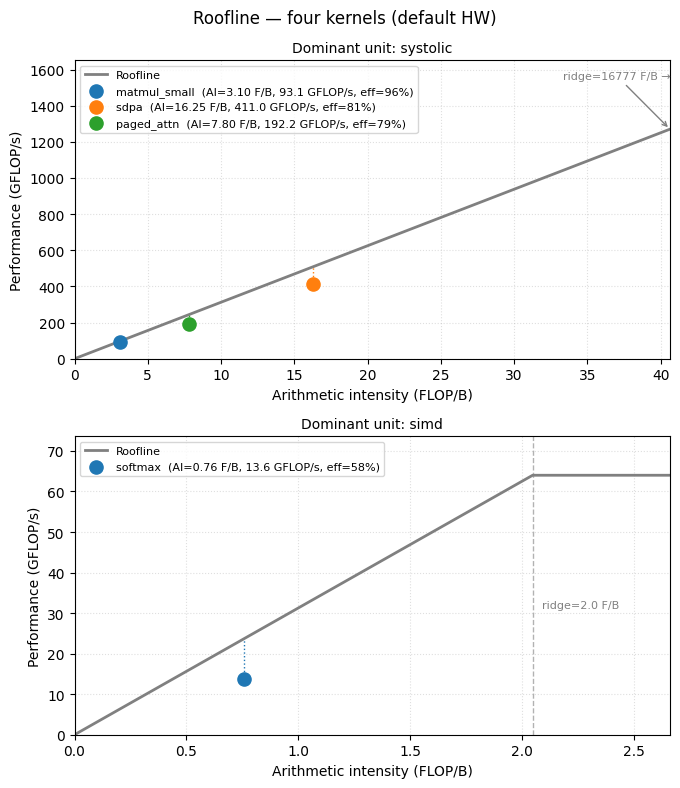

In [28]:
plot_roofline(
    hw,
    [("matmul_small", report), ("sdpa", sdpa_report),
     ("softmax", softmax_report), ("paged_attn", paged_attn_report)],
    title="Roofline — four kernels (default HW)",
)


## 5. Tuning HardwareConfig

`HardwareConfig` lets you model different hardware targets by adjusting bandwidth, clock, and SIMD width.
All fields default to reasonable approximations — override with real Spyre specs when available.

In [29]:
# High-bandwidth variant: 4× HBM bandwidth
hw_hbw = HardwareConfig(
    num_cores=32,
    clock_ghz=1.5,
    hbm_bandwidth_tb_s=4.0,   # 4 TB/s aggregate
    simd_elements_per_cycle=128,
)

interp_hbw = KTIRInterpreter(latency_config=hw_hbw)
interp_hbw.load(str(_LATENCY / "softmax_small.mlir"))
interp_hbw.execute_function(
    "softmax_kernel_small",
    output_ptr=np.zeros((64, 64), dtype=np.float16),
    input_ptr=np.random.randn(64, 64).astype(np.float16),
    n_rows=64,
)
r_hbw = interp_hbw.get_latency_report()

print(f"Default HW  : {softmax_report.kernel_cycles:.0f} cycles  bottleneck={softmax_report.bottleneck}")
print(f"High-BW HW  : {r_hbw.kernel_cycles:.0f} cycles  bottleneck={r_hbw.bottleneck}")

Default HW  : 28 cycles  bottleneck=memory
High-BW HW  : 12 cycles  bottleneck=memory


## 6. MLIR frontend parser (optional)

By default `KTIRInterpreter` uses the built-in regex parser.
The MLIR frontend uses the real MLIR C++ bindings for full-fidelity parsing.

See the [README](../README.md#mlir-frontend-bindings-optional) for build and install instructions.

In [30]:
try:
    from ktir_cpu.mlir_frontend.parser import MLIRFrontendParser
    _mlir_available = True
except ImportError:
    _mlir_available = False
    print("mlir_ktdp not installed — skipping MLIR frontend cells.")
    print("See the install instructions above.")

In [31]:
if _mlir_available:
    # Pass MLIRFrontendParser directly to the interpreter
    mlir_interp = KTIRInterpreter(
        latency_config=hw,
        parser=MLIRFrontendParser(),
    )
    mlir_interp.load(str(_LATENCY / "matmul_small.mlir"))

    M, K, N = 16, 64, 64
    mlir_interp.execute_function(
        "matmul_kernel_small",
        a_ptr=np.random.rand(M, K).astype(np.float16),
        b_ptr=np.random.rand(K, N).astype(np.float16),
        c_ptr=np.zeros((M, N), dtype=np.float16),
        K=K, BLOCK_SIZE_M=8, BLOCK_SIZE_N=32, BLOCK_SIZE_K=32,
    )

    mlir_report = mlir_interp.get_latency_report()
    print(mlir_report)

KTIR Latency Estimation Report
  Kernel cycles : 352
  Kernel time   : 0.352 us
  Bottleneck    : memory
  Cores         : 4
------------------------------------------------------------
  Core       Compute        Memory          Comm         Total
------------------------------------------------------------
     0             8           344             0           352
     1             8           344             0           352
     2             8           344             0           352
     3             8           344             0           352

Roofline Analysis (critical-path core)
------------------------------------------------------------
  Arithmetic intensity : 3.10 FLOP/B
  Peak bandwidth       : 31.25 GB/s
  Dominant unit        : systolic
  Efficiency           : 96.2%  (dominant unit)

        Unit      Achieved       Ceiling       Ridge      Eff
  ----------  ------------  ------------  ----------  -------
 *   systolic       93.06 G       96.73 G   16777.2 F/B  

In [32]:
if _mlir_available:
    rf_regex = report.roofline()
    rf_mlir  = mlir_report.roofline()
    print(f"regex  cycles={report.kernel_cycles:.0f}  AI={rf_regex['arithmetic_intensity']:.2f}")
    print(f"mlir   cycles={mlir_report.kernel_cycles:.0f}  AI={rf_mlir['arithmetic_intensity']:.2f}")
    print("Results are identical — the two parsers produce the same IR.")

regex  cycles=352  AI=3.10
mlir   cycles=352  AI=3.10
Results are identical — the two parsers produce the same IR.


## Summary

```python
from ktir_cpu.interpreter import KTIRInterpreter
from ktir_cpu.latency import HardwareConfig

hw = HardwareConfig()                        # or HardwareConfig(clock_ghz=1.5, ...)
interp = KTIRInterpreter(latency_config=hw)  # add parser=MLIRFrontendParser() for MLIR
interp.load("path/to/kernel.mlir")           # or inline MLIR text

interp.execute_function("kernel_name", arg=tensor, ...)

report = interp.get_latency_report()
print(report)                        # human-readable table + roofline
report.kernel_cycles                 # float
report.kernel_time_us                # float
report.bottleneck                    # 'compute' | 'memory' | 'comm'
report.per_core_summary()            # list[dict] — per-core breakdown
report.roofline()                    # dict — arithmetic intensity, efficiency, ...
```